# Text Flappy Bird

In this notebook we are going to work on a text based flappy bird and implement multiple agents to solve the game.

## **Imports**

In [ ]:
# Section 1: Imports
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import text_flappy_bird_gym
from tqdm import trange
from tqdm import tqdm
from datetime import datetime
import itertools
import random
import pickle
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import itertools
import pandas as pd
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

In [3]:
def save_policy(agent, name="mcns_policy", include_timestamp=True):
    """
    Saves only the agent's Q-table to the 'weights' directory.
    """    
    # Generate filename
    filename = name
    if include_timestamp:
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"{filename}_{ts}"
    
    file_path = f"weights/{filename}.pkl"
    
    # Convert defaultdict to regular dict for pickling
    q_to_save = dict(agent.Q)
    
    with open(file_path, 'wb') as f:
        pickle.dump(q_to_save, f)
        
    print(f"Policy Q saved to: {file_path}")
    return file_path

**Plot functions**

In [4]:
PALETTE={
    "DARK_RED":"#780000",
    "RED":"#c1121f",
    "BEIGE":"#fdf0d5",
    "DARK_BLUE":"#003049",
    "LIGHT_BLUE":"#669bbc",
}
hex_palette = [
    "#03045e", "#023e8a", "#0077b6", "#0096c7", 
    "#00b4d8", "#48cae4", "#90e0ef", "#ade8f4", "#caf0f8"
]

def plot_rewards(rewards, window=100, title=None):
    moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
    # Create indices starting from 1 for the log scale compatibility
    indices = np.arange(1, len(rewards) + 1)
    ma_indices = np.arange(window, len(rewards) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    # --- Linear Plot ---
    ax1.plot(indices, rewards, alpha=0.3, label='Episode Reward', color=PALETTE["LIGHT_BLUE"])
    ax1.plot(ma_indices, moving_avg, label=f'{window}-Episode Moving Avg', color=PALETTE["DARK_BLUE"])
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Total Reward')
    ax1.set_title(f"{title} (Linear Scale)" if title else "Linear Scale")
    ax1.legend()

    # --- Log Plot ---
    ax2.plot(indices, rewards, alpha=0.3, label='Episode Reward', color=PALETTE["RED"])
    ax2.plot(ma_indices, moving_avg, label=f'{window}-Episode Moving Avg', color=PALETTE["DARK_RED"])
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Total Reward (Log Scale)')
    ax2.set_yscale('log')
    ax2.set_xlim(window, len(rewards))
    ax2.set_title(f"{title} (Log Scale)" if title else "Log Scale")
    ax2.legend()

    plt.tight_layout()
    plt.show()

## **No Screen**

#### **Monte Carlo Agent**

We are going to build a Monte Carlo Control algorithm. We are going the reward at every state visit.

Since flappy bird could be played forever we are going to consider that reaching a reward of 1000 is considered a win.

In [5]:
class MonteCarloNoScreenAgent:
    def __init__(self, env, gamma=0.99, epsilon=0.5, alpha=0.1, epsilon_decay=None):
        self.env = env
        self.gamma = gamma
        self.epsilon = epsilon
        self.alpha = alpha 
        self.epsilon_decay = epsilon_decay
        self.Q = defaultdict(lambda: [0.0, 0.0]) # List is faster than np.array for size 2
        self.max_score = 1000

    def generate_episode(self):
        episode = []
        state, _ = self.env.reset()
        done = False
        total_reward = 0
        
        while not done:
            # Faster random selection
            if random.random() < self.epsilon:
                action = self.env.action_space.sample()
            else:
                # Manual argmax is faster for 2 elements
                qs = self.Q[state]
                action = 1 if qs[1] > qs[0] else 0
            
            next_state, reward, done, _, _ = self.env.step(action)
            episode.append((state, action, reward))
            state = next_state
            total_reward += reward
            
            # Simple score cap
            if total_reward >= self.max_score:
                break
                
        return episode, total_reward

    def update_Q(self, episode):
        G = 0
        # Every-visit MC
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = self.gamma * G + reward
            
            # Direct update
            q_val = self.Q[state][action]
            self.Q[state][action] = q_val + self.alpha * (G - q_val)

    def train(self, num_episodes=1000, verbose=True):
        all_rewards = []
        iterator = trange(num_episodes) if verbose else range(num_episodes)

        # Cache local references for speed
        generate = self.generate_episode
        update = self.update_Q

        for i in iterator:
            episode, total_reward = generate()
            update(episode)
            all_rewards.append(total_reward)

            if self.epsilon_decay:
                self.epsilon = max(0.01, self.epsilon - self.epsilon_decay)
        
        return all_rewards

**Train the agent**

In [8]:
noscreen_env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
num_episodes = 100000
epsilon_decay= 0.1/80000 # First 80k episodes are exploratory, then epsilon is 0
mcns_trainer = MonteCarloNoScreenAgent(noscreen_env, gamma=0.8, epsilon=0.1, alpha=0.1, epsilon_decay=epsilon_decay)
rewards = mcns_trainer.train(num_episodes=num_episodes)
# Save Q to check
#save_policy(mcns_trainer, name="mcns_policy")

  0%|          | 0/100000 [00:00<?, ?it/s]

100%|██████████| 100000/100000 [07:12<00:00, 231.36it/s]


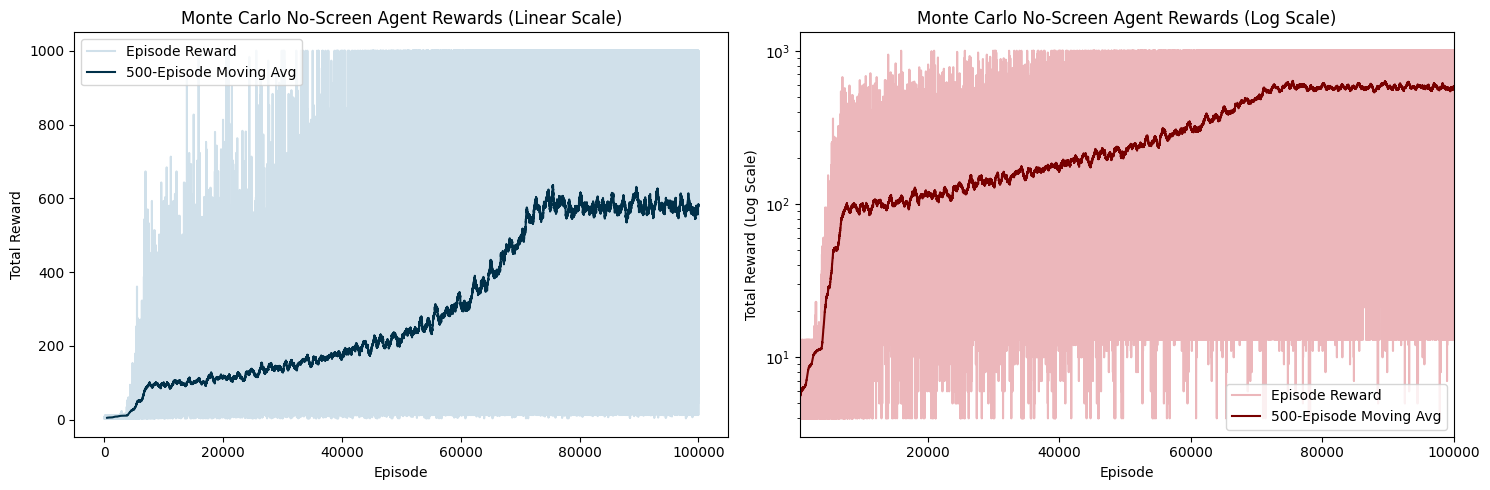

In [9]:
plot_rewards(rewards, window=500, title="Monte Carlo No-Screen Agent Rewards")

We see that the agent improves very fast at the beginning (<10k episodes), then slowly learns until the 70k episodes, at which point it stabilizes into a plateau. I tried a lot of parameters before getting this plot, this is the best one with the epsilon decay.

Based on the graph we can decide which hyperparameters we want to optimize:
- Gamma: This decide on whether we focus on short term or long term, this has to be optimized.
- Alpha: This is more about the speed of learning, and capacity to hold on to new knowledge, this doesn't seem to be this important because it doesn't appear as if we suddenly managed to improve the agent and then lost this knowledge.
- Epsilon: This is about how much we explore. This is more about making the results stable. We are not going to optimize this parameter instead we are using a linear decay to reduce epsilon over time but so that it is still relevant for our number of episodes.
- Epsilon Decay: This would be nice to optimize.

Since this code is very slow, and I want to run it for 100k episodes, I'm going to test each parameter one at a time instead of combinations.

**Study on each hyperparameter**

Parameters: 100%|██████████| 4/4 [2:50:04<00:00, 2551.20s/it]


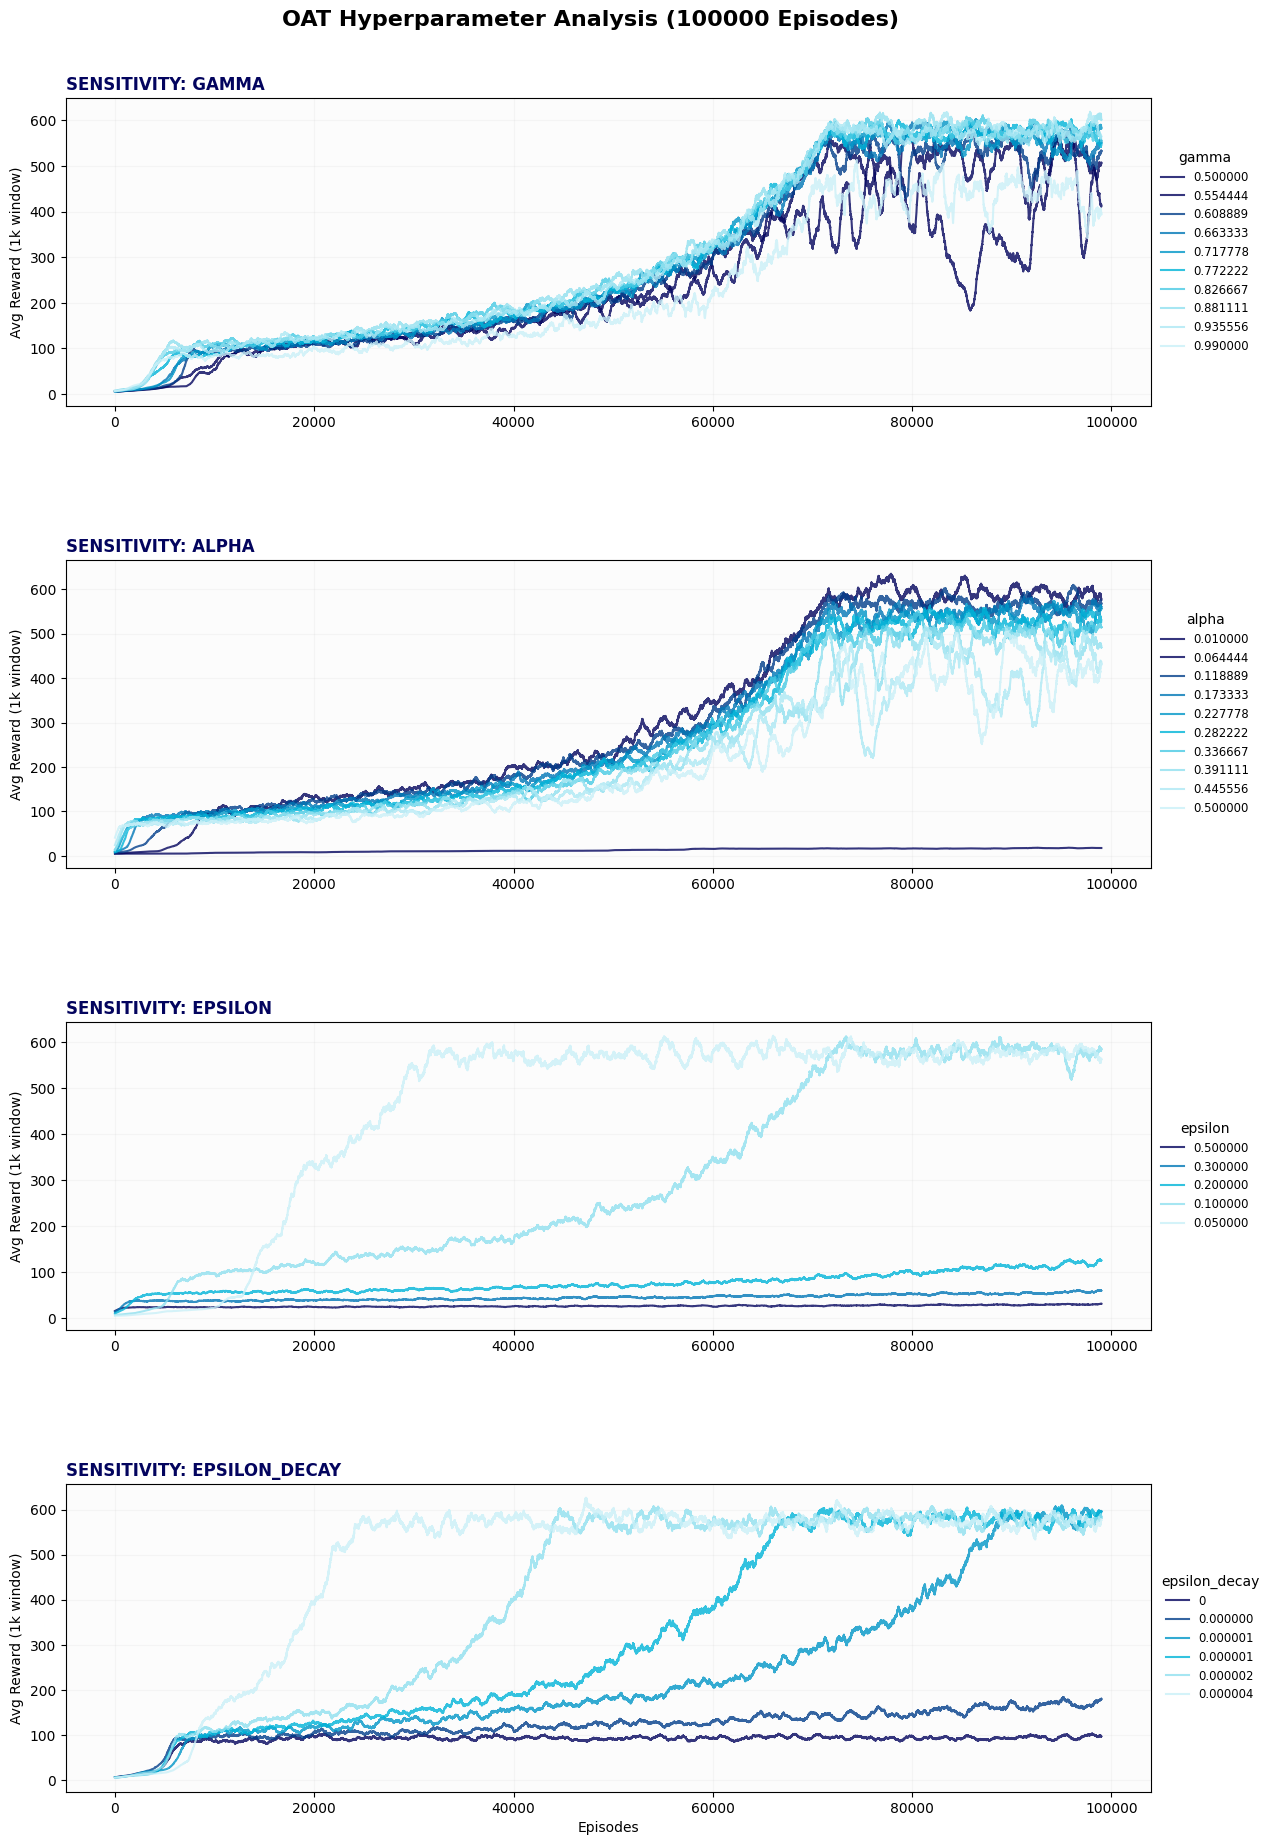

In [23]:
# --- 1. Parameters & Direct Hex Palette ---
HEX_PALETTE = [
    "#03045e", "#023e8a", "#0077b6", "#0096c7", 
    "#00b4d8", "#48cae4", "#90e0ef", "#ade8f4", "#caf0f8"
]

NUM_EPISODES = 100000
BASE_PARAMETERS = {
    "gamma": 0.8,
    "alpha": 0.1,
    "epsilon": 0.1,
    "epsilon_decay": 0.1/80000,
}

PARAMETER_GRIDS = {
    "gamma": np.linspace(0.5, 0.99, 10),
    "alpha": np.linspace(0.01, 0.5, 10),
    "epsilon": [0.5, 0.3, 0.2, 0.1, 0.05],
    "epsilon_decay": [0, 0.1/200000, 0.1/100000, 0.1/75000, 0.1/50000, 0.1/25000],
}

def train_and_get_history(params):
    env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
    # Re-using your optimized MonteCarloNoScreenAgent class
    agent = MonteCarloNoScreenAgent(
        env, 
        gamma=params["gamma"], 
        alpha=params["alpha"], 
        epsilon=params["epsilon"], 
        epsilon_decay=params["epsilon_decay"]
    )
    rewards = agent.train(num_episodes=NUM_EPISODES, verbose=False)
    
    # 1000-episode moving average
    return np.convolve(rewards, np.ones(1000)/1000, mode='valid')

# --- 2. Sequential Execution ---
all_results = {}

for param_name, grid_values in tqdm(PARAMETER_GRIDS.items(), desc="Parameters"):
    param_histories = []
    
    # Use tqdm for the inner loop
    for val in tqdm(grid_values, desc=f"Testing {param_name}"):
        current_run_params = BASE_PARAMETERS.copy()
        current_run_params[param_name] = val
        
        history = train_and_get_history(current_run_params)
        param_histories.append(history)
        
    all_results[param_name] = param_histories

# --- 3. Plotting with Direct Hex Access ---
fig, axes = plt.subplots(len(PARAMETER_GRIDS), 1, figsize=(14, 22))
plt.subplots_adjust(hspace=0.5)

for i, (param_name, histories) in enumerate(all_results.items()):
    ax = axes[i]
    grid_vals = PARAMETER_GRIDS[param_name]
    n = len(histories)
    
    for idx, history in enumerate(histories):
        # Manually pick hex based on progress through the grid
        # Scaling index to the 9 available hex colors
        color_idx = int((idx / (n - 1)) * (len(HEX_PALETTE) - 1)) if n > 1 else 0
        hex_color = HEX_PALETTE[color_idx]
        
        val_str = f"{grid_vals[idx]:.6f}" if isinstance(grid_vals[idx], float) else str(grid_vals[idx])
        ax.plot(history, color=hex_color, linewidth=1.5, alpha=0.8, label=val_str)
    
    ax.set_title(f"SENSITIVITY: {param_name.upper()}", loc='left', fontweight='bold', color="#03045e")
    ax.set_ylabel("Avg Reward (1k window)")
    ax.grid(True, alpha=0.1)
    ax.legend(title=param_name, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, fontsize='small')
    ax.set_facecolor('#fcfcfc')

axes[-1].set_xlabel("Episodes")
plt.suptitle(f"OAT Hyperparameter Analysis ({NUM_EPISODES} Episodes)", fontsize=16, y=0.92, fontweight='bold')
plt.show()

It is interesting to see that each parameter influence in its own way the reward. But the problem is that no parameter combination was able to go over 600. It is weird because the coded limit is set to 1000.

  0%|          | 0/40000 [00:00<?, ?it/s]

100%|██████████| 40000/40000 [03:25<00:00, 194.46it/s]


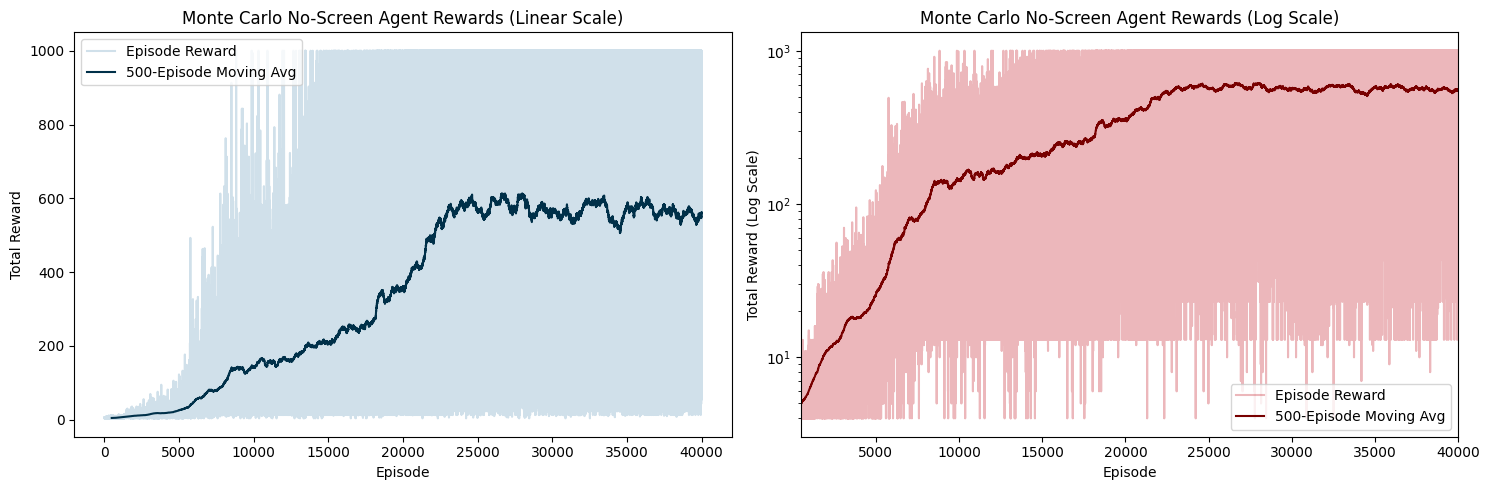

In [6]:
noscreen_env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
num_episodes = 40000
epsilon_decay= 0.1/25000 # First 80k episodes are exploratory, then epsilon is 0
mcns_trainer = MonteCarloNoScreenAgent(noscreen_env, gamma=0.8, epsilon=0.1, alpha=0.1, epsilon_decay=epsilon_decay)
rewards = mcns_trainer.train(num_episodes=num_episodes)
# Save Q to check
#save_policy(mcns_trainer, name="mcns_policy")
plot_rewards(rewards, window=500, title="Monte Carlo No-Screen Agent Rewards")

#### **Sarsa Agent**

In [6]:
class SarsaNoScreenAgent:
    def __init__(self, env, gamma=0.99, alpha=0.1, epsilon=0.1, lambd=0.9, epsilon_decay=None, min_epsilon=0.01, alpha_decay=None, alpha_min=0.01):
        self.env = env
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.lambd = lambd
        self.Q = defaultdict(lambda: np.zeros(env.action_space.n))
        self.action_space_n = env.action_space.n
        self.max_score = 1000
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.alpha_decay = alpha_decay
        self.alpha_min = alpha_min

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return self.env.action_space.sample()
        else:
            return np.argmax(self.Q[state])

    def train(self, num_episodes=1000, verbose=True):
        episode_rewards = []
        iterator = trange(num_episodes) if verbose else range(num_episodes)
        for ep in iterator:
            state, _ = self.env.reset()
            action = self.choose_action(state)
            z = defaultdict(lambda: np.zeros(self.action_space_n))  # eligibility traces
            done = False
            total_reward = 0
            while not done:
                next_state, reward, done, _, _ = self.env.step(action)
                next_action = self.choose_action(next_state)
                delta = reward + self.gamma * self.Q[next_state][next_action] - self.Q[state][action]
                z[state][action] += 1
                # Only update actions with nonzero traces
                threshold = 1e-6
                states_to_remove = []
                for s in z:
                    # Set very small values to zero
                    z[s][np.abs(z[s]) < threshold] = 0.0
                    # If all actions are zero, mark for removal
                    if np.all(z[s] == 0.0):
                        states_to_remove.append(s)

                    nonzero_actions = np.nonzero(z[s])[0]
                    for a in nonzero_actions:
                        self.Q[s][a] += self.alpha * delta * z[s][a]
                        z[s][a] *= self.gamma * self.lambd
                for s in states_to_remove:
                    del z[s]
                state = next_state
                action = next_action
                total_reward += reward
                if total_reward >= self.max_score:
                    break
            episode_rewards.append(total_reward)
            if self.epsilon_decay is not None and self.epsilon > self.min_epsilon:
                self.epsilon = max(self.min_epsilon, self.epsilon - self.epsilon_decay)
            if self.alpha_decay is not None and self.alpha > self.alpha_min:
                self.alpha = max(self.alpha_min, self.alpha - self.alpha_decay)
        return episode_rewards

100%|██████████| 10000/10000 [17:24<00:00,  9.57it/s]


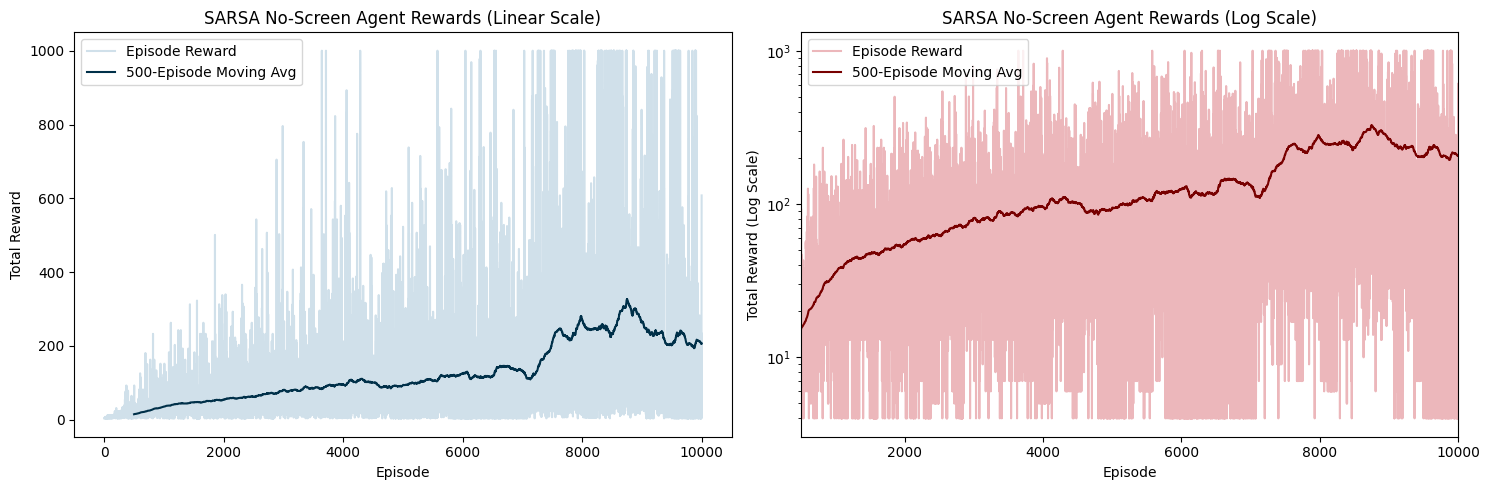

In [28]:
noscreen_env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
num_episodes = 10000
epsilon_decay = 0.1/8000 # First 8k episodes are exploratory, then epsilon is 0
alpha_decay = 1/5000   # Decay alpha from 0.2 to 0.01 over 8k episodes
sarsa_trainer = SarsaNoScreenAgent(
    noscreen_env, gamma=0.8, alpha=1, epsilon=0.1, lambd=0.9,
    epsilon_decay=epsilon_decay, alpha_decay=alpha_decay, alpha_min=0.2
)

sarsa_rewards = sarsa_trainer.train(num_episodes=num_episodes)

plot_rewards(sarsa_rewards, window=500, title="SARSA No-Screen Agent Rewards")

My observation is that Sarsa is much more efficient, as it learns really well in around 8k episodes compared to Monte Carlo. However it is heavier on the computer: the online updates are slowing down the simulation. At its peak, the MC agent was running 100 it/s and reaching 1k score with a 60% rate, here the Sarsa agent runs at 2 it/s and reaches 1k 40% of time. This is significantly slower and makes it hard to find good hyperparameters.

#### Testing the agent on a different screen resolution

In [91]:
eval_env = gym.make(
    "TextFlappyBird-v0",
    height=20,
    width=30,
    pipe_gap=5
)

n_games = 1000
max_score = getattr(mcns_trainer, "max_score", 1000)

wins = 0
episode_rewards = []

for _ in range(n_games):
    state, _ = eval_env.reset()
    total_reward = 0.0
    done = False

    while not done and total_reward < max_score:
        # Use the trained policy from mcns_trainer
        if state in mcns_trainer.Q:
            qvals = mcns_trainer.Q[state]
            action = 1 if qvals[1] > qvals[0] else 0
        else:
            # Unseen state fallback
            action = eval_env.action_space.sample()

        next_state, reward, terminated, truncated, _ = eval_env.step(action)
        done = terminated or truncated
        state = next_state
        total_reward += reward

    wins += int(total_reward >= max_score)
    episode_rewards.append(total_reward)

eval_env.close()

win_share = wins / n_games
print(f"Wins: {wins}/{n_games}")
print(f"Share of wins: {win_share:.4f} ({100*win_share:.2f}%)")
print(f"Mean reward: {np.mean(episode_rewards):.2f}")
print(f"Median reward: {np.median(episode_rewards):.2f}")

Wins: 4/1000
Share of wins: 0.0040 (0.40%)
Mean reward: 138.69
Median reward: 84.00


# SCREEN

Now I will look into the screen version

In [35]:
class MonteCarloScreenAgent:
    def __init__(self, env, gamma=0.99, epsilon=0.5, alpha=0.1, epsilon_decay=None):
        self.env = env
        self.gamma = gamma
        self.epsilon = epsilon
        self.alpha = alpha 
        self.epsilon_decay = epsilon_decay
        self.Q = defaultdict(lambda: [0.0, 0.0]) # List is faster than np.array for size 2
        self.max_score = 1000
    
    def obs_to_state(self, obs):
        # Convert the screen (array) to a hashable tuple for tabular MC
        return tuple(obs.flatten())

    def generate_episode(self):
        episode = []
        obs, _ = self.env.reset()
        state = self.obs_to_state(obs)
        done = False
        total_reward = 0
        
        while not done:
            # Faster random selection
            if random.random() < self.epsilon:
                action = self.env.action_space.sample()
            else:
                # Manual argmax is faster for 2 elements
                qs = self.Q[state]
                action = 1 if qs[1] > qs[0] else 0
            
            next_obs, reward, done, _, _ = self.env.step(action)
            next_state = self.obs_to_state(next_obs)
            episode.append((state, action, reward))
            state = next_state
            total_reward += reward
            
            # Simple score cap
            if total_reward >= self.max_score:
                break
                
        return episode, total_reward

    def update_Q(self, episode):
        G = 0
        # Every-visit MC: Faster and converges similarly for Flappy Bird
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = self.gamma * G + reward
            
            # Direct update
            q_val = self.Q[state][action]
            self.Q[state][action] = q_val + self.alpha * (G - q_val)

    def train(self, num_episodes=1000, verbose=True):
        all_rewards = []
        iterator = trange(num_episodes) if verbose else range(num_episodes)

        # Cache local references for speed
        generate = self.generate_episode
        update = self.update_Q

        for i in iterator:
            episode, total_reward = generate()
            update(episode)
            all_rewards.append(total_reward)

            if self.epsilon_decay:
                self.epsilon = max(0.01, self.epsilon - self.epsilon_decay)
        
        return all_rewards

In [39]:
screen_env = gym.make('TextFlappyBird-screen-v0', height=15, width=20, pipe_gap=4)
num_episodes = 100000
epsilon_decay= 0.1/80000
screen_mc_trainer = MonteCarloScreenAgent(screen_env, gamma=0.8, epsilon=0.1, alpha=0.1, epsilon_decay=epsilon_decay)
screen_rewards = screen_mc_trainer.train(num_episodes=num_episodes)

100%|██████████| 100000/100000 [27:45<00:00, 60.05it/s] 


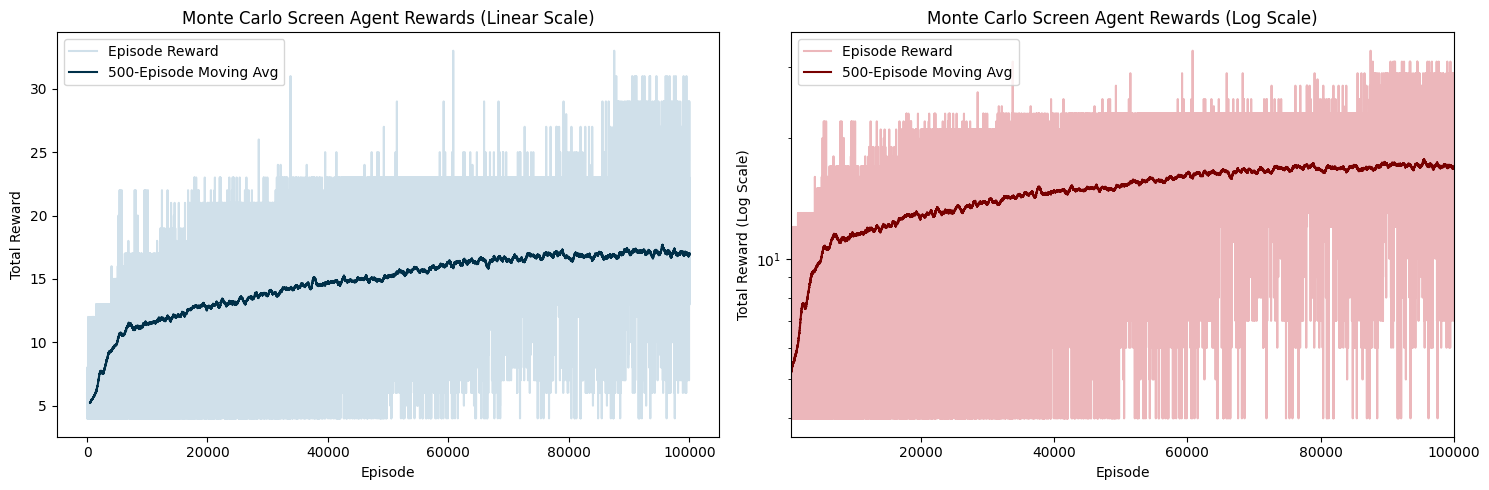

In [40]:
plot_rewards(screen_rewards, window=500, title="Monte Carlo Screen Agent Rewards")

Using the same parameters as before it seems that there won't be any convergence. Instead of trying ot push the program I will try to use an autoencoder to make the state more discrete.

## **Auto Encoder + Monte Carlo**

It took more time than necessary since I had to find a good trade off between a low loss and low number of states.

I created a dataset of frames by letting the previous MC agent playing games. I collected 100 games of 1000 moves.

In [10]:
# Collect frames from 100 episodes played by the No-Screen Monte Carlo policy
def collect_mc_noscreen_frames(agent, num_games=100, max_score=1000, eval_epsilon=0.0):
    env = agent.env
    all_frames = []
    episode_lengths = []
    
    for ep in trange(num_games):
        state, _ = env.reset()
        done = False
        total_reward = 0
        steps = 0

        while not done and total_reward < max_score:
            # Epsilon-greedy action from the trained MC Q-table
            if np.random.rand() < eval_epsilon or state not in agent.Q:
                action = env.action_space.sample()
            else:
                qvals = agent.Q[state]
                action = 1 if qvals[1] > qvals[0] else 0

            state, reward, done, _, _ = env.step(action)
            total_reward += reward
            steps += 1

            # Trigger frame construction and read matrix from env internals
            _ = env.render()
            frame = env.unwrapped._render.copy().astype(np.float32)
            all_frames.append(frame)

        episode_lengths.append(steps)

    frames = np.stack(all_frames, axis=0)
    print(f"Collected {frames.shape[0]} frames from {num_games} games.")
    print(f"Average episode length: {np.mean(episode_lengths):.2f}")
    print(f"Frame shape: {frames.shape[1:]} | value range: [{frames.min()}, {frames.max()}]")
    return frames

# Requires mcns_trainer from the no-screen MC section
mc_noscreen_frames = collect_mc_noscreen_frames(mcns_trainer, num_games=100, max_score=1000, eval_epsilon=0.0)

100%|██████████| 100/100 [00:38<00:00,  2.59it/s]


Collected 100000 frames from 100 games.
Average episode length: 1000.00
Frame shape: (20, 15) | value range: [0.0, 2.0]


**Model Definition**

Now that we have the dataset I created autoencoders. I originally thought that pure MLP would work better because I expected the model to learn distance and placement, and convolution network are invariant to translations. However I tried all three architecture that I thought would yield results:
- MLP
- Linear then Conv
- Conv then Linear

In [ ]:
# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

frames = mc_noscreen_frames.astype(np.float32)
N, H, W = frames.shape
print(f"Frames: N={N}, H={H}, W={W}")

# Build only a TRAIN dataset/loader (raw frames: values in {0,1,2})
X_train_t = torch.from_numpy(frames[:, None, :, :])
train_loader = DataLoader(TensorDataset(X_train_t), batch_size=256, shuffle=True)


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class _BaseAE(nn.Module):
    def __init__(self, input_h, input_w, latent_scale=9.999999):
        super().__init__()
        self.input_h = input_h
        self.input_w = input_w
        self.input_dim = input_h * input_w
        self.latent_scale = latent_scale

    def _bound_latent(self, z_raw):
        # sigmoid bounds to [0, 1], then scale to [0, latent_scale]
        return self.latent_scale * torch.sigmoid(z_raw)

    def encode_integer(self, x):
        return torch.floor(self.encode(x))


class ConvThenLinearAE(_BaseAE):
    # Encoder: conv -> linear(latent), Decoder: linear -> deconv
    def __init__(self, input_h, input_w, latent_dim=4, hidden_dim=128, latent_scale=9.999999):
        super().__init__(input_h, input_w, latent_scale=latent_scale)
        c1 = max(8, hidden_dim // 16)
        c2 = max(16, hidden_dim // 8)

        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, c1, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(c1, c2, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_h, input_w)
            enc_shape = self.encoder_conv(dummy).shape[1:]
            flat_dim = int(np.prod(enc_shape))

        self.enc_shape = enc_shape
        self.encoder_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )

        self.decoder_head = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, flat_dim),
            nn.ReLU(),
        )

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(c2, c1, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(c1, 1, kernel_size=4, stride=2, padding=1),
        )

    def encode(self, x):
        x = x - 1.0
        h = self.encoder_conv(x)
        z_raw = self.encoder_head(h)
        return self._bound_latent(z_raw)

    def decode(self, z):
        h = self.decoder_head(z)
        h = h.view(-1, *self.enc_shape)
        x_hat = self.decoder_conv(h)
        x_hat = x_hat[:, :, :self.input_h, :self.input_w]
        return x_hat + 1.0

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z)
        return recon, z


class LinearThenConvAE(_BaseAE):
    # Encoder: linear(latent), Decoder: linear -> deconv
    def __init__(self, input_h, input_w, latent_dim=4, hidden_dim=128, latent_scale=9.999999):
        super().__init__(input_h, input_w, latent_scale=latent_scale)
        c2 = max(16, hidden_dim // 8)

        feat_h = (input_h + 3) // 4
        feat_w = (input_w + 3) // 4
        self.dec_shape = (c2, feat_h, feat_w)
        self.dec_flat = c2 * feat_h * feat_w

        self.encoder_mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )

        self.decoder_head = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, self.dec_flat),
            nn.ReLU(),
        )

        c1 = max(8, hidden_dim // 16)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(c2, c1, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(c1, 1, kernel_size=4, stride=2, padding=1),
        )

    def encode(self, x):
        x = x - 1.0
        z_raw = self.encoder_mlp(x)
        return self._bound_latent(z_raw)

    def decode(self, z):
        h = self.decoder_head(z)
        h = h.view(-1, *self.dec_shape)
        x_hat = self.decoder_conv(h)
        x_hat = x_hat[:, :, :self.input_h, :self.input_w]
        return x_hat + 1.0

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z)
        return recon, z


class MLPOnlyAE(_BaseAE):
    # Encoder: linear(latent), Decoder: linear
    def __init__(self, input_h, input_w, latent_dim=4, hidden_dim=128, latent_scale=9.999999):
        super().__init__(input_h, input_w, latent_scale=latent_scale)
        self.encoder_mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )
        self.decoder_mlp = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, self.input_dim),
        )

    def encode(self, x):
        x = x - 1.0
        z_raw = self.encoder_mlp(x)
        return self._bound_latent(z_raw)

    def decode(self, z):
        x_hat = self.decoder_mlp(z)
        x_hat = x_hat.view(-1, 1, self.input_h, self.input_w)
        return x_hat + 1.0

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z)
        return recon, z


def build_model(model_type, input_h, input_w, latent_dim=4, hidden_dim=128, latent_scale=9.999999):
    if model_type == "conv_then_linear":
        return ConvThenLinearAE(input_h, input_w, latent_dim, hidden_dim, latent_scale)
    if model_type == "linear_then_conv":
        return LinearThenConvAE(input_h, input_w, latent_dim, hidden_dim, latent_scale)
    if model_type == "mlp_only":
        return MLPOnlyAE(input_h, input_w, latent_dim, hidden_dim, latent_scale)
    raise ValueError(f"Unknown model_type: {model_type}")

Frames: N=100000, H=20, W=15


**Model Explanation**
The goal is to train an autoencoder that will turn frames into small vectors then to disretize those vectors into integer vectors which are going to create the states. This is why we need to keep track of the interger loss which is different than the normal loss. The normal loss is the auto-encoder reconstruction loss. Since I couldn't use function to round the values without makign the gradient impossible to compute I had to use this trick. So the model isn't train on discretization unfortunately. However I use this integer loss (reconstruction loss from the floored encoded vector) to evaluate the models.


I created a function to train them easily

In [ ]:
def train_autoencoder(config):
    """
    Train one model configuration with early stopping on integer loss.
    Returns: (trained_model, losses, integer_losses, best_integer_loss)
    """
    default_cfg = {
        "model_type": "conv_then_linear",
        "latent_dim": 4,
        "hidden_dim": 128,
        "latent_scale": 9.999999,
        "epochs": 20,
        "batch_size": 256,
        "lr": 1e-3,
        "weight_decay": 1e-5,
        "noise_std": 0.0,
        "grad_clip": 1.0,
        "patience": 3,
        "min_delta": 1e-5,
        "seed": 42,
        "verbose": True,
    }
    cfg = {**default_cfg, **config}

    np.random.seed(cfg["seed"])
    torch.manual_seed(cfg["seed"])

    loader = DataLoader(TensorDataset(X_train_t), batch_size=cfg["batch_size"], shuffle=True)

    model = build_model(
        model_type=cfg["model_type"],
        input_h=H,
        input_w=W,
        latent_dim=cfg["latent_dim"],
        hidden_dim=cfg["hidden_dim"],
        latent_scale=cfg["latent_scale"],
    )

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
    )

    losses = []
    integer_losses = []
    best_int_loss = float("inf")
    best_state = None
    no_improve = 0

    epochs_iter = trange(1, cfg["epochs"] + 1, desc=f"Train {cfg['model_type']}", disable=not cfg["verbose"])
    for epoch in epochs_iter:
        model.train()
        running = 0.0
        running_int = 0.0
        seen = 0

        for (x,) in loader:
            if cfg["noise_std"] > 0.0:
                x_in = x + cfg["noise_std"] * torch.randn_like(x)
            else:
                x_in = x

            optimizer.zero_grad(set_to_none=True)

            recon, _ = model(x_in)
            loss = criterion(recon, x)

            with torch.no_grad():
                z_int = model.encode_integer(x_in)
                recon_int = model.decode(z_int)
                int_loss = criterion(recon_int, x)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            optimizer.step()

            running += loss.item() * x.size(0)
            running_int += int_loss.item() * x.size(0)
            seen += x.size(0)

        epoch_loss = running / max(seen, 1)
        epoch_int_loss = running_int / max(seen, 1)
        losses.append(epoch_loss)
        integer_losses.append(epoch_int_loss)

        if cfg["verbose"]:
            epochs_iter.set_postfix(loss=f"{epoch_loss:.6f}", int_loss=f"{epoch_int_loss:.6f}")

        if epoch_int_loss < (best_int_loss - cfg["min_delta"]):
            best_int_loss = epoch_int_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= cfg["patience"]:
            if cfg["verbose"]:
                print(f"Early stopping at epoch {epoch}. Best integer loss={best_int_loss:.6f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, losses, integer_losses, best_int_loss

**Test run**

In [43]:
# Small example run
train_cfg = {
    "model_type": "conv_then_linear",
    "latent_dim": 4,
    "hidden_dim": 128,
    "latent_scale": 8,
    "epochs": 20,
    "patience": 3,
}

ae_model, train_losses, train_integer_losses, best_integer_loss = train_autoencoder(train_cfg)
print("Done. Best integer loss:", best_integer_loss)
print("Trainable params:", count_trainable_params(ae_model))

Train conv_then_linear:  35%|███▌      | 7/20 [02:11<04:03, 18.75s/it, int_loss=0.075389, loss=0.036075]

Early stopping at epoch 8. Best integer loss=0.069776
Done. Best integer loss: 0.06977594267129898
Trainable params: 86957


**Optimize hyperparameters**

Given all the settings we have, it's imperative I found a good combination that would yield a very low loss while also keeping the number of states low.

In [ ]:
# Grid requested by user
latent_dims = [2, 4, 6, 8]
hidden_dims = [64, 128, 256, 512]
latent_scales = [2, 4, 8, 16]
model_types = ["conv_then_linear", "linear_then_conv", "mlp_only"]

all_setups = list(itertools.product(model_types, latent_dims, hidden_dims, latent_scales))
print(f"Total setups: {len(all_setups)}")  # 192

results = []

for run_idx, (model_type, latent_dim, hidden_dim, latent_scale) in enumerate(tqdm(all_setups, desc="Sweeping 192 setups"), start=1):
    cfg = {
        "model_type": model_type,
        "latent_dim": latent_dim,
        "hidden_dim": hidden_dim,
        "latent_scale": latent_scale,
        "epochs": 20,
        "patience": 3,
        "verbose": False,
    }

    model_i, losses_i, int_losses_i, best_int_i = train_autoencoder(cfg)

    result_row = {
        "run_idx": run_idx,
        "model_type": model_type,
        "latent_dim": latent_dim,
        "hidden_dim": hidden_dim,
        "latent_scale": latent_scale,
        "best_int_loss": float(best_int_i),
        "final_int_loss": float(int_losses_i[-1]),
        "final_loss": float(losses_i[-1]),
        "epochs_ran": len(losses_i),
        "num_params": count_trainable_params(model_i),
    }
    results.append(result_row)

    # Live print per completed run
    print(
        f"[{run_idx:03d}/{len(all_setups)}] "
        f"model={model_type}, latent_dim={latent_dim}, hidden_dim={hidden_dim}, latent_scale={latent_scale} "
        f"-> best_int_loss={result_row['best_int_loss']:.6f}, final_int_loss={result_row['final_int_loss']:.6f}, "
        f"epochs={result_row['epochs_ran']}, params={result_row['num_params']}"
    )

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("best_int_loss", ascending=True).reset_index(drop=True)

print("Top 10 overall setups by best integer loss:")
display(results_df.head(10))

print("\nBest setup per model type:")
best_per_model = results_df.loc[results_df.groupby("model_type")["best_int_loss"].idxmin()].sort_values("best_int_loss")
display(best_per_model)

print("\nComparison by latent_dim (mean best_int_loss):")
by_latent_dim = results_df.groupby("latent_dim", as_index=False)["best_int_loss"].mean().sort_values("best_int_loss")
display(by_latent_dim)

print("\nComparison by hidden_dim (mean best_int_loss):")
by_hidden_dim = results_df.groupby("hidden_dim", as_index=False)["best_int_loss"].mean().sort_values("best_int_loss")
display(by_hidden_dim)

print("\nComparison by latent_scale (mean best_int_loss):")
by_latent_scale = results_df.groupby("latent_scale", as_index=False)["best_int_loss"].mean().sort_values("best_int_loss")
display(by_latent_scale)

print("\nPivot table by model_type x latent_dim (mean best_int_loss):")
pivot_model_latent = results_df.pivot_table(
    index="model_type", columns="latent_dim", values="best_int_loss", aggfunc="mean"
)
display(pivot_model_latent)

# Optional: save raw sweep results for later analysis
os.makedirs("plots", exist_ok=True)
results_csv = "plots/ae_sweep_results.csv"
results_df.to_csv(results_csv, index=False)
print(f"Saved full sweep results to: {results_csv}")

Total setups: 192


Sweeping 192 setups:   1%|          | 1/192 [01:05<3:28:30, 65.50s/it]

[001/192] model=conv_then_linear, latent_dim=2, hidden_dim=64, latent_scale=2 -> best_int_loss=0.356015, final_int_loss=0.469912, epochs=5, params=45099


Sweeping 192 setups:   1%|          | 2/192 [03:00<4:58:41, 94.33s/it]

[002/192] model=conv_then_linear, latent_dim=2, hidden_dim=64, latent_scale=4 -> best_int_loss=0.207644, final_int_loss=0.229964, epochs=7, params=45099


...


Comparison by latent_scale (mean best_int_loss):


,latent_scale,best_int_loss
3,16,0.047844
2,8,0.072448
1,4,0.133409
0,2,0.271719



Pivot table by model_type x latent_dim (mean best_int_loss):


latent_dim,2,4,6,8
model_type,,,,
conv_then_linear,0.193696,0.120926,0.103961,0.096891
linear_then_conv,0.189784,0.131579,0.118882,0.087462
mlp_only,0.205854,0.123696,0.104083,0.099445


Saved full sweep results to: plots/ae_sweep_results.csv


**Plotting the results**

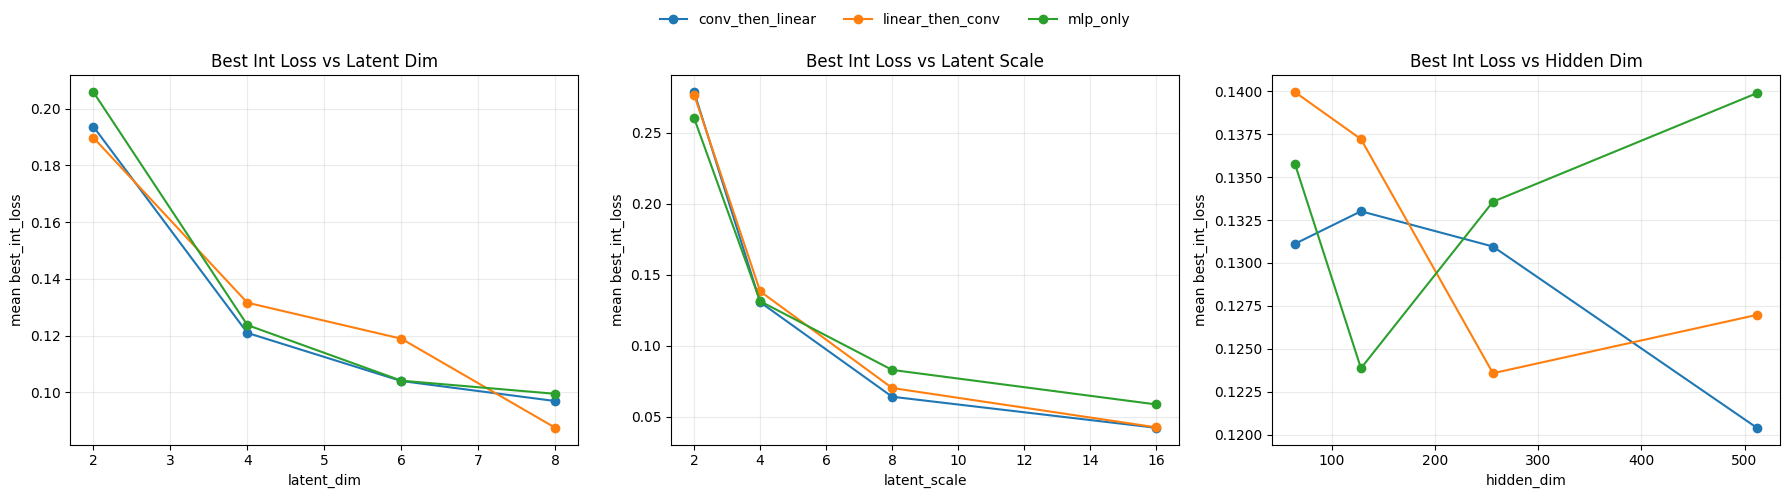

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_order = sorted(results_df["model_type"].unique())

# 1) best_int_loss vs latent_dim
ax = axes[0]
for model_name in model_order:
    sub = results_df[results_df["model_type"] == model_name]
    curve = (
        sub.groupby("latent_dim", as_index=False)["best_int_loss"]
        .min()
        .sort_values("latent_dim")
    )
    ax.plot(curve["latent_dim"], curve["best_int_loss"], marker="o", label=model_name)
ax.set_title("Best Int Loss vs Latent Dim")
ax.set_xlabel("latent_dim")
ax.set_ylabel("mean best_int_loss")
ax.grid(alpha=0.25)

# 2) best_int_loss vs latent_scale
ax = axes[1]
for model_name in model_order:
    sub = results_df[results_df["model_type"] == model_name]
    curve = (
        sub.groupby("latent_scale", as_index=False)["best_int_loss"]
        .mean()
        .sort_values("latent_scale")
    )
    ax.plot(curve["latent_scale"], curve["best_int_loss"], marker="o", label=model_name)
ax.set_title("Best Int Loss vs Latent Scale")
ax.set_xlabel("latent_scale")
ax.set_ylabel("mean best_int_loss")
ax.grid(alpha=0.25)

# 3) best_int_loss vs hidden_dim
ax = axes[2]
for model_name in model_order:
    sub = results_df[results_df["model_type"] == model_name]
    curve = (
        sub.groupby("hidden_dim", as_index=False)["best_int_loss"]
        .mean()
        .sort_values("hidden_dim")
    )
    ax.plot(curve["hidden_dim"], curve["best_int_loss"], marker="o", label=model_name)
ax.set_title("Best Int Loss vs Hidden Dim")
ax.set_xlabel("hidden_dim")
ax.set_ylabel("mean best_int_loss")
ax.grid(alpha=0.25)

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(model_order), frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

We see a clear pattern:
- Increasing latent_dim makes the prediction better
- Increasing latent_scale makes the prediction better
- Model architectures have little to no influence on the results
- The dimension of the model is random - However this is hard to believe and may be due to the small sample size.

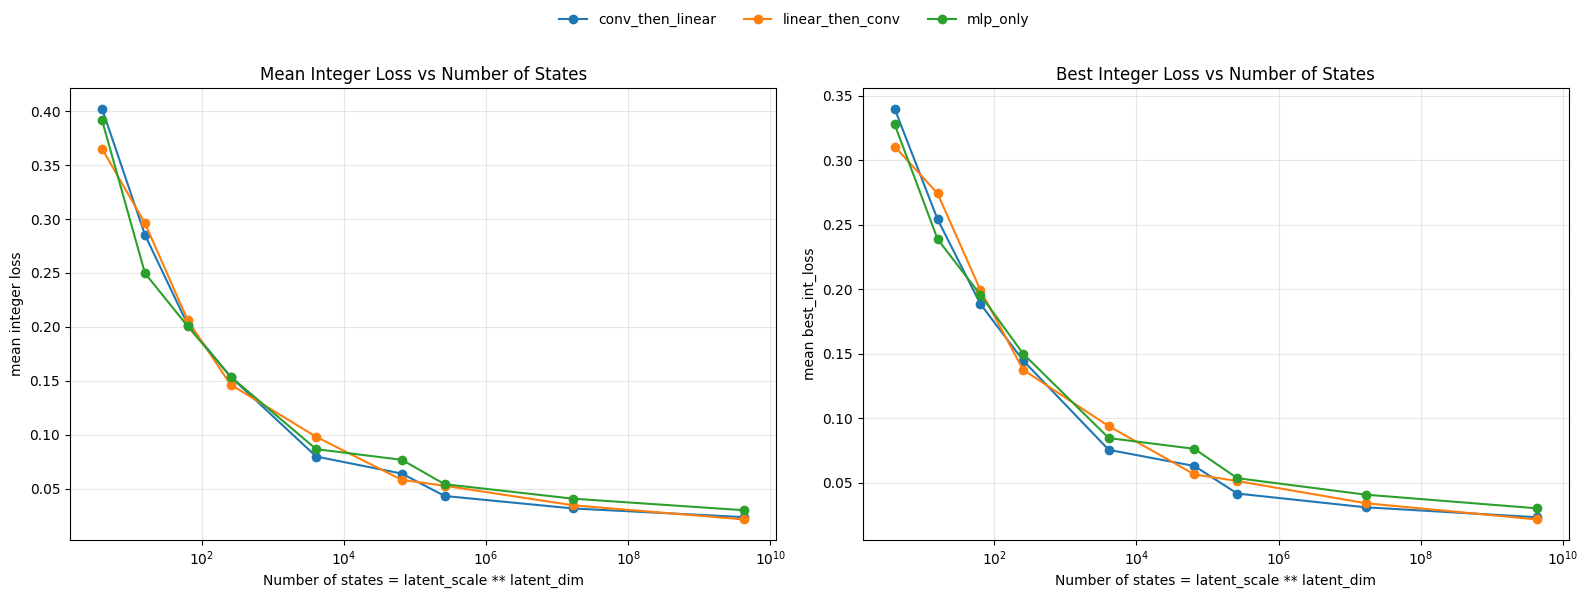

In [ ]:
plot_df = results_df.copy()
plot_df["num_states"] = plot_df["latent_scale"] ** plot_df["latent_dim"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
ax_mean, ax_best = axes
model_order = sorted(plot_df["model_type"].unique())

for model_name in model_order:
    sub = plot_df[plot_df["model_type"] == model_name]

    mean_curve = (
        sub.groupby("num_states", as_index=False)["final_int_loss"]
        .mean()
        .sort_values("num_states")
    )
    best_curve = (
        sub.groupby("num_states", as_index=False)["best_int_loss"]
        .mean()
        .sort_values("num_states")
    )

    ax_mean.plot(mean_curve["num_states"], mean_curve["final_int_loss"], marker="o", label=model_name)
    ax_best.plot(best_curve["num_states"], best_curve["best_int_loss"], marker="o", label=model_name)

ax_mean.set_xscale("log")
ax_mean.set_xlabel("Number of states = latent_scale ** latent_dim")
ax_mean.set_ylabel("mean integer loss")
ax_mean.set_title("Mean Integer Loss vs Number of States")
ax_mean.grid(alpha=0.3, which="both")

ax_best.set_xscale("log")
ax_best.set_xlabel("Number of states = latent_scale ** latent_dim")
ax_best.set_ylabel("mean best_int_loss")
ax_best.set_title("Best Integer Loss vs Number of States")
ax_best.grid(alpha=0.3, which="both")

handles, labels = ax_mean.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(model_order), frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

Independently of the architecture and the parameters, the loss seems to be dictated by the number of states we allow. Since we plan on having a montecarlo, we chose to be around 10k states. We are going to choose the conv_then_linear architecture with a hidden dimension of 512.

I then wondered if there was a difference in how those states were created.

**Latent_scale vs Latent_dim**

Training selected combinations:   7%|▋         | 1/15 [02:53<40:30, 173.58s/it]

[01/15] scale=2, dim=12, num_states=4096 -> final_int=0.289296, best_int=0.241053


Training selected combinations:  13%|█▎        | 2/15 [04:51<30:34, 141.13s/it]

[02/15] scale=4, dim=6, num_states=4096 -> final_int=0.113347, best_int=0.106747


Training selected combinations:  20%|██        | 3/15 [07:11<28:06, 140.57s/it]

...

Training selected combinations:  93%|█████████▎| 14/15 [49:26<03:04, 184.38s/it]

[14/15] scale=5, dim=5, num_states=3125 -> final_int=0.087208, best_int=0.080925


Training selected combinations: 100%|██████████| 15/15 [51:24<00:00, 205.63s/it]

[15/15] scale=7, dim=4, num_states=2401 -> final_int=0.079350, best_int=0.076642
Saved combination results to: plots/ae_selected_state_scale_combinations.csv
Results sorted by best_int_loss:


,run_idx,model_type,hidden_dim,latent_scale,latent_dim,num_states,final_int_loss,best_int_loss,epochs_ran,num_params
0,10,conv_then_linear,128,20,3,8000,0.049634,0.049604,15,86700
1,4,conv_then_linear,128,16,3,4096,0.056048,0.055129,15,86700
2,11,conv_then_linear,128,100,2,10000,0.062097,0.062097,20,86443
3,8,conv_then_linear,128,6,5,7776,0.064532,0.063222,10,87214
4,9,conv_then_linear,128,9,4,6561,0.077656,0.063548,8,86957
5,5,conv_then_linear,128,64,2,4096,0.065751,0.064611,19,86443
6,3,conv_then_linear,128,8,4,4096,0.075389,0.069776,8,86957
7,15,conv_then_linear,128,7,4,2401,0.079350,0.076642,7,86957
8,14,conv_then_linear,128,5,5,3125,0.087208,0.080925,8,87214
9,13,conv_then_linear,128,3,8,6561,0.108791,0.105275,6,87985


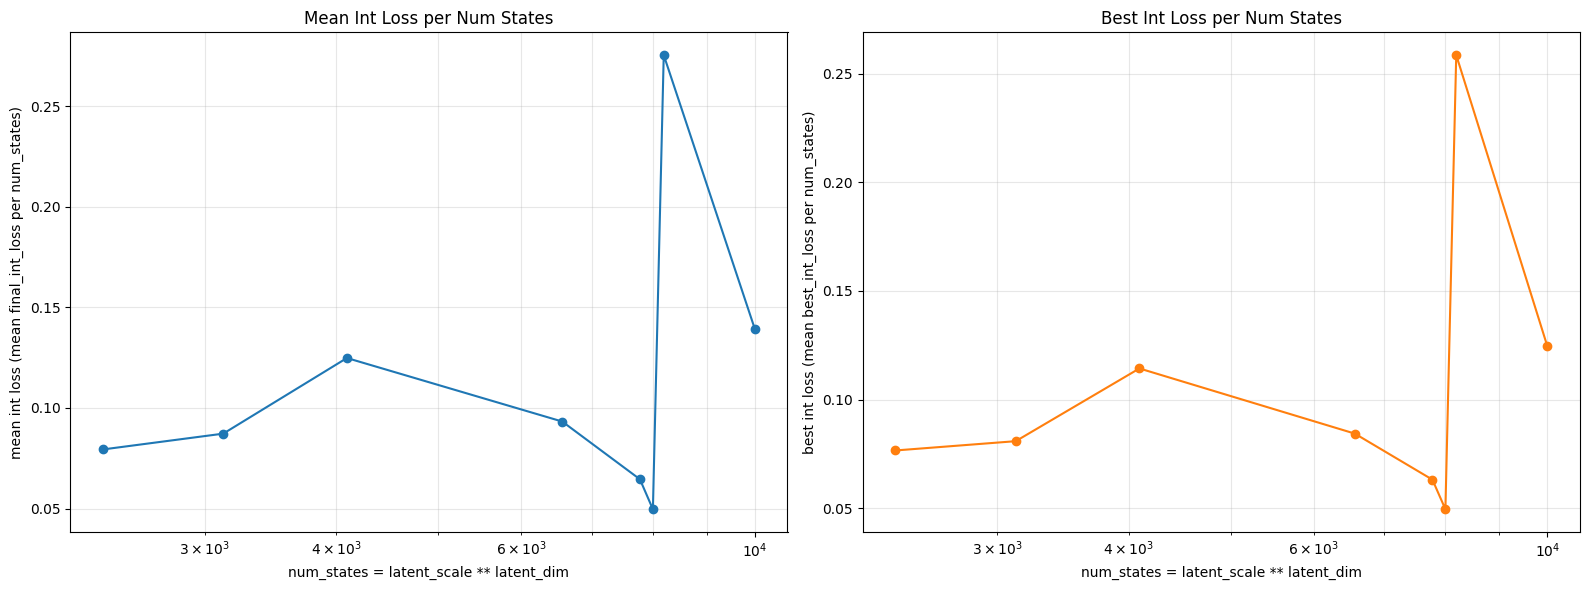

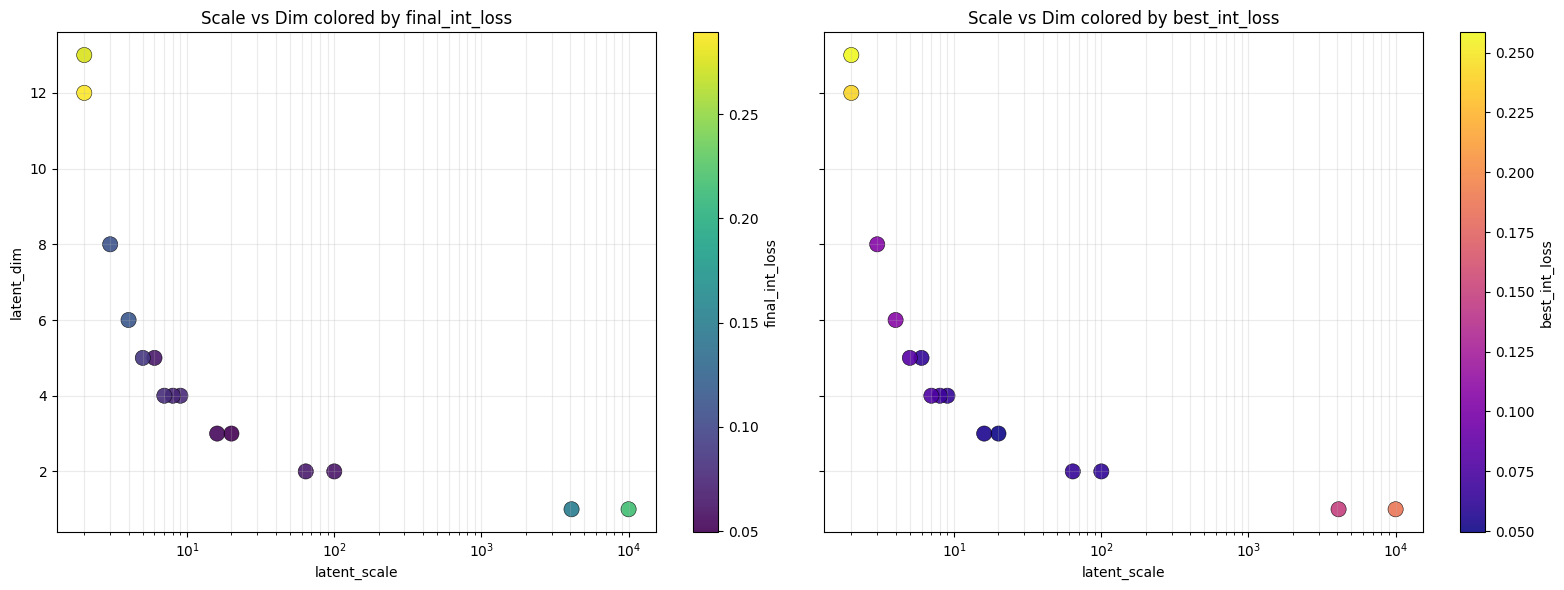

In [ ]:
# Requested combinations
state_scale_combinations = [
    (2, 12), (4, 6), (8, 4), (16, 3), (64, 2), (4096, 1),
    (2, 13), (6, 5), (9, 4), (20, 3), (100, 2), (10000, 1),
    (3, 8), (5, 5), (7, 4),
]

combo_results = []

for run_idx, (latent_scale, latent_dim) in enumerate(tqdm(state_scale_combinations, desc="Training selected combinations"), start=1):
    num_states = latent_scale ** latent_dim

    cfg = {
        "model_type": "conv_then_linear",
        "hidden_dim": 128,
        "latent_dim": int(latent_dim),
        "latent_scale": float(latent_scale),
        "epochs": 20,
        "patience": 3,
        "verbose": False,
    }

    model_i, losses_i, int_losses_i, best_int_i = train_autoencoder(cfg)

    row = {
        "run_idx": run_idx,
        "model_type": "conv_then_linear",
        "hidden_dim": 128,
        "latent_scale": int(latent_scale),
        "latent_dim": int(latent_dim),
        "num_states": int(num_states),
        "final_int_loss": float(int_losses_i[-1]),
        "best_int_loss": float(best_int_i),
        "epochs_ran": len(int_losses_i),
        "num_params": count_trainable_params(model_i),
    }
    combo_results.append(row)

    print(
        f"[{run_idx:02d}/{len(state_scale_combinations)}] "
        f"scale={latent_scale}, dim={latent_dim}, num_states={num_states} "
        f"-> final_int={row['final_int_loss']:.6f}, best_int={row['best_int_loss']:.6f}"
    )

combo_results_df = pd.DataFrame(combo_results).sort_values("best_int_loss").reset_index(drop=True)

# Save results
os.makedirs("plots", exist_ok=True)
combo_results_csv = "plots/ae_selected_state_scale_combinations.csv"
combo_results_df.to_csv(combo_results_csv, index=False)
print(f"Saved combination results to: {combo_results_csv}")

# Display results
print("Results sorted by best_int_loss:")
display(combo_results_df)

# Aggregate by number of states across trained runs
agg_per_states = (
    combo_results_df
    .groupby("num_states", as_index=False)
    .agg(
        mean_int_loss=("final_int_loss", "mean"),
        best_int_loss=("best_int_loss", "mean"),
    )
    .sort_values("num_states")
)

# Plot 1 and 2: mean int loss and best int loss per num_states
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
ax_mean, ax_best = axes

ax_mean.plot(agg_per_states["num_states"], agg_per_states["mean_int_loss"], marker="o")
ax_mean.set_xscale("log")
ax_mean.set_xlabel("num_states = latent_scale ** latent_dim")
ax_mean.set_ylabel("mean int loss (mean final_int_loss per num_states)")
ax_mean.set_title("Mean Int Loss per Num States")
ax_mean.grid(alpha=0.3, which="both")

ax_best.plot(agg_per_states["num_states"], agg_per_states["best_int_loss"], marker="o", color="tab:orange")
ax_best.set_xscale("log")
ax_best.set_xlabel("num_states = latent_scale ** latent_dim")
ax_best.set_ylabel("best int loss (mean best_int_loss per num_states)")
ax_best.set_title("Best Int Loss per Num States")
ax_best.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

# Plot 3: scatter latent_scale vs latent_dim colored by int loss
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
ax_scatter_mean, ax_scatter_best = axes

sc_mean = ax_scatter_mean.scatter(
    combo_results_df["latent_scale"],
    combo_results_df["latent_dim"],
    c=combo_results_df["final_int_loss"],
    cmap="viridis",
    s=120,
    edgecolors="black",
    linewidths=0.4,
    alpha=0.9,
    marker="o",
)
ax_scatter_mean.set_xscale("log")
ax_scatter_mean.set_xlabel("latent_scale")
ax_scatter_mean.set_ylabel("latent_dim")
ax_scatter_mean.set_title("Scale vs Dim colored by final_int_loss")
ax_scatter_mean.grid(alpha=0.25, which="both")
cbar_mean = plt.colorbar(sc_mean, ax=ax_scatter_mean)
cbar_mean.set_label("final_int_loss")

sc_best = ax_scatter_best.scatter(
    combo_results_df["latent_scale"],
    combo_results_df["latent_dim"],
    c=combo_results_df["best_int_loss"],
    cmap="plasma",
    s=120,
    edgecolors="black",
    linewidths=0.4,
    alpha=0.9,
    marker="o",
)
ax_scatter_best.set_xscale("log")
ax_scatter_best.set_xlabel("latent_scale")
ax_scatter_best.set_title("Scale vs Dim colored by best_int_loss")
ax_scatter_best.grid(alpha=0.25, which="both")
cbar_best = plt.colorbar(sc_best, ax=ax_scatter_best)
cbar_best.set_label("best_int_loss")

plt.tight_layout()
plt.show()

Model chose : latent_scale : 20, lantent_dim : 3. Num of parameters 8000.

In [72]:
train_cfg = {
    "model_type": "conv_then_linear",
    "hidden_dim": 128,
    "latent_scale": 20.0,
    "latent_dim": 3,
    "epochs": 20,
    "patience": 3,
    "verbose": True,
}

ae_model, train_losses, train_integer_losses, best_integer_loss = train_autoencoder(train_cfg)

print("Trained ae_model with chosen config:")
print(train_cfg)
print(f"num_states={int(train_cfg['latent_scale'] ** train_cfg['latent_dim'])}")
print(f"best_integer_loss={best_integer_loss:.6f}")
print(f"final_integer_loss={train_integer_losses[-1]:.6f}")
print(f"trainable_params={count_trainable_params(ae_model)}")

Train conv_then_linear:  70%|███████   | 14/20 [04:34<01:57, 19.60s/it, int_loss=0.049634, loss=0.037012]

Early stopping at epoch 15. Best integer loss=0.049604
Trained ae_model with chosen config:
{'model_type': 'conv_then_linear', 'hidden_dim': 128, 'latent_scale': 20.0, 'latent_dim': 3, 'epochs': 20, 'patience': 3, 'verbose': True}
num_states=8000
best_integer_loss=0.049604
final_integer_loss=0.049634
trainable_params=86700


Obtaining a integer loss of 0.05 given only 8k states is pretty decent. Let's observe what it looks like.

In [ ]:
model_to_use = ae_model
model_to_use.eval()

# -------------------- Take first 1000 frames --------------------
n_frames = min(1000, mc_noscreen_frames.shape[0])
frames_1000 = mc_noscreen_frames[:n_frames].astype(np.float32)
x = torch.from_numpy(frames_1000[:, None, :, :])

# -------------------- Encode -> decode raw/floored --------------------
with torch.no_grad():
    z = model_to_use.encode(x)                # (n_frames, latent_dim)
    z_floor = torch.floor(z)

    x_rec_raw = model_to_use.decode(z)        # decode from raw encoded
    x_rec_floor = model_to_use.decode(z_floor)  # decode from floored encoded

z_np = z.cpu().numpy()
z_floor_np = z_floor.cpu().numpy()
recon_raw_np = np.clip(x_rec_raw.squeeze(1).cpu().numpy(), 0.0, 2.0)
recon_floor_np = np.clip(x_rec_floor.squeeze(1).cpu().numpy(), 0.0, 2.0)

print(f"Processed frames: {n_frames}")
print(f"Latent shape: {z_np.shape} | Raw min/max: {z_np.min():.3f}/{z_np.max():.3f}")
print(f"Floored min/max: {z_floor_np.min():.1f}/{z_floor_np.max():.1f}")

# -------------------- Animate GIF with 4 panels --------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
ax1, ax2, ax3, ax4 = axes.ravel()

im1 = ax1.imshow(frames_1000[0], cmap="viridis", vmin=0, vmax=2, interpolation="nearest")
im2 = ax2.imshow(z_np[0][None, :], cmap="magma", aspect="auto", interpolation="nearest")
im3 = ax3.imshow(recon_raw_np[0], cmap="viridis", vmin=0, vmax=2, interpolation="nearest")
im4 = ax4.imshow(recon_floor_np[0], cmap="viridis", vmin=0, vmax=2, interpolation="nearest")

ax1.set_title("Original")
ax2.set_title("Encoded (raw)")
ax3.set_title("Decoded from raw encoded")
ax4.set_title("Decoded from floored encoded")

ax1.set_xticks([])
ax1.set_yticks([])
ax3.set_xticks([])
ax3.set_yticks([])
ax4.set_xticks([])
ax4.set_yticks([])

# Encoded axis shows latent dimensions
ax2.set_yticks([])
ax2.set_xticks(np.arange(z_np.shape[1]))
ax2.set_xlabel("Latent dim")

title = fig.suptitle("Frame 0")


def update(i):
    im1.set_data(frames_1000[i])
    im2.set_data(z_np[i][None, :])
    im3.set_data(recon_raw_np[i])
    im4.set_data(recon_floor_np[i])
    title.set_text(f"Frame {i}")
    return im1, im2, im3, im4, title

anim = FuncAnimation(fig, update, frames=n_frames, interval=40, blit=False)

os.makedirs("plots", exist_ok=True)
gif_path = "plots/latent_raw_vs_floored_reconstruction.gif"
anim.save(gif_path, writer=PillowWriter(fps=25))
plt.close(fig)

print(f"GIF saved to: {gif_path}")
display(Image(filename=gif_path))

**Encoded Monte Carlo Agent**

This is a simple Monte Carlo Agent that uses the encoder to observe the frame.

In [80]:
class MonteCarloScreenEncodedAgent:
    def __init__(self, env, encoder_model, gamma=0.99, epsilon=0.5, alpha=0.1, epsilon_decay=None):
        self.env = env
        self.encoder = encoder_model
        self.gamma = gamma
        self.epsilon = epsilon
        self.alpha = alpha
        self.epsilon_decay = epsilon_decay
        self.Q = defaultdict(lambda: [0.0, 0.0])
        self.max_score = 1000

        # Keep encoder frozen and in eval mode
        self.encoder.eval()
        self.device = next(self.encoder.parameters()).device

    def obs_to_state(self, obs):
        # Encode raw screen frame to compact discrete latent state
        x = torch.from_numpy(obs.astype(np.float32))[None, None, :, :].to(self.device)
        with torch.no_grad():
            z_int = self.encoder.encode_integer(x).squeeze(0).cpu().numpy().astype(np.int16)
        return tuple(z_int.tolist())

    def generate_episode(self):
        episode = []
        obs, _ = self.env.reset()
        state = self.obs_to_state(obs)
        done = False
        total_reward = 0

        while not done:
            if random.random() < self.epsilon:
                action = self.env.action_space.sample()
            else:
                qs = self.Q[state]
                action = 1 if qs[1] > qs[0] else 0

            next_obs, reward, done, _, _ = self.env.step(action)
            next_state = self.obs_to_state(next_obs)

            episode.append((state, action, reward))
            state = next_state
            total_reward += reward

            if total_reward >= self.max_score:
                break

        return episode, total_reward

    def update_Q(self, episode):
        G = 0.0
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = self.gamma * G + reward
            q_val = self.Q[state][action]
            self.Q[state][action] = q_val + self.alpha * (G - q_val)

    def train(self, num_episodes=1000, verbose=True):
        all_rewards = []
        iterator = trange(num_episodes, desc="MC Screen+Encoder") if verbose else range(num_episodes)

        generate = self.generate_episode
        update = self.update_Q

        for _ in iterator:
            episode, total_reward = generate()
            update(episode)
            all_rewards.append(total_reward)

            if self.epsilon_decay:
                self.epsilon = max(0.01, self.epsilon - self.epsilon_decay)

        return all_rewards

In [81]:
# Start encoded Monte Carlo training (100k games)
screen_env_encoded = gym.make('TextFlappyBird-screen-v0', height=15, width=20, pipe_gap=4)

num_episodes_encoded = 100000
epsilon_decay_encoded = 0.1 / 80000

mc_screen_encoded_trainer = MonteCarloScreenEncodedAgent(
    screen_env_encoded,
    encoder_model=ae_model,
    gamma=0.8,
    epsilon=0.1,
    alpha=0.1,
    epsilon_decay=epsilon_decay_encoded,
)

screen_encoded_rewards = mc_screen_encoded_trainer.train(
    num_episodes=num_episodes_encoded,
    verbose=True,
)

print("Encoded-screen MC training done.")
print(f"Episodes: {len(screen_encoded_rewards)}")
print(f"Mean reward: {np.mean(screen_encoded_rewards):.3f}")
print(f"Max reward: {np.max(screen_encoded_rewards):.3f}")

MC Screen+Encoder:   0%|          | 0/100000 [00:00<?, ?it/s]

MC Screen+Encoder: 100%|██████████| 100000/100000 [2:09:07<00:00, 12.91it/s] 

Encoded-screen MC training done.
Episodes: 100000
Mean reward: 42.837
Max reward: 573.000


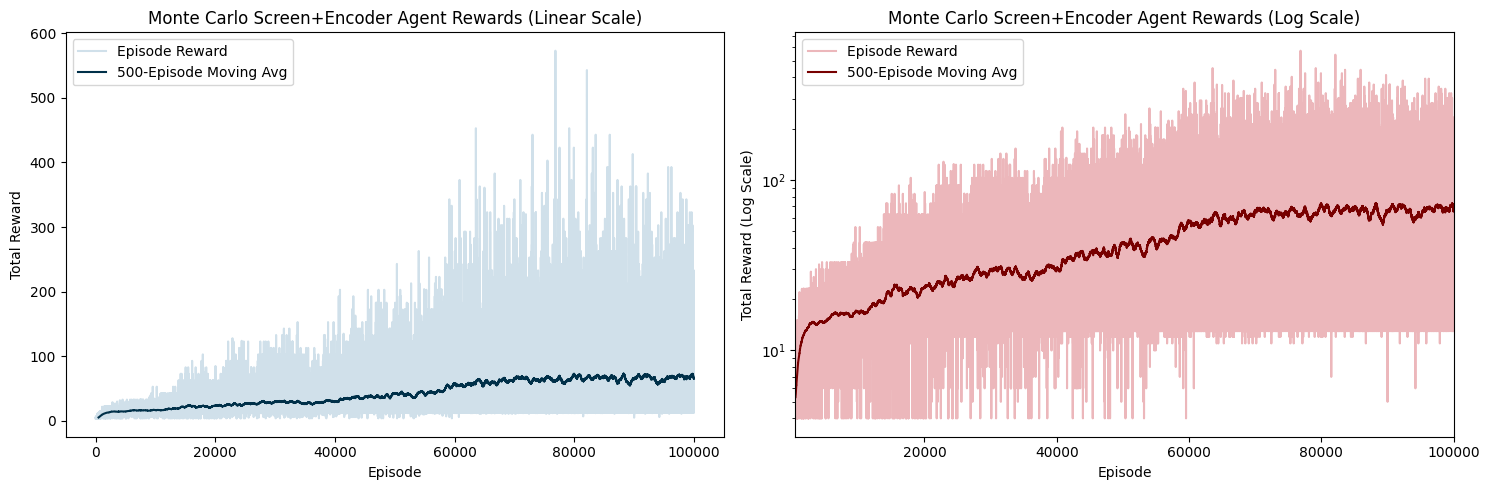

In [82]:
plot_rewards(screen_encoded_rewards, window=500, title="Monte Carlo Screen+Encoder Agent Rewards")